In [24]:
import pandas as pd

df=pd.read_csv('DA_outbound_call_nursing_team.csv')
print(df.info())
#let's drop duplicate rows:
df=df.drop_duplicates()
print(df.info())
print(df.isna().sum())

#patient_id: trimming the spaces
df['patient_id']=df['patient_id'].str.strip()
print(df.info())

#checking the available screening_type:
print(df['screening_type'].unique())

#THERE IS ONE MORE CATEGORY A1C
df = df.drop(df[df['screening_type'] == 'A1C'].index)

# screening_completed_ind:
#we can drop rows(patients) who weren't eligible for any of the screenings, as we won't use this data in our analysis:
df=df.dropna(subset='screening_completed_ind')

#Checking the unique values and converting to boolean:
print('Unique values for screening_completed_ind:')
print(df['screening_completed_ind'].unique())

def convert_to_boolean(var):
    if var in ['1.0', 's']:
        return True
    else:
        return False
        
df['screening_completed_ind']=df['screening_completed_ind'].apply(convert_to_boolean).astype('boolean')
print(df['screening_completed_ind'].info())

#'latest_call_date' and 'screening_date' columns:
date_cols= ['latest_call_date','screening_date']
df[['latest_call_date','screening_date']]=df[date_cols].apply(pd.to_datetime, format='%Y-%m-%d',errors='coerce')

# 'reached_ind' column: unique values and converting to boolean
print('Unique values of reached_ind:')
print(df['reached_ind'].unique())

def conv_to_bool(x):
    if x in ['1.0', '1 and reached']:
        return True
    elif x == '0.0':
        return False
    else:
        return pd.NA
        
df['reached_ind']=df['reached_ind'].apply(conv_to_bool).astype('boolean')

#let's check the result after cleaning:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1988 entries, 0 to 1987
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   patient_id               1988 non-null   object
 1   screening_type           1988 non-null   object
 2   screening_completed_ind  1375 non-null   object
 3   latest_call_date         1740 non-null   object
 4   reached_ind              1740 non-null   object
 5   screening_date           1380 non-null   object
dtypes: object(6)
memory usage: 93.3+ KB
None
<class 'pandas.core.frame.DataFrame'>
Int64Index: 669 entries, 0 to 1987
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   patient_id               669 non-null    object
 1   screening_type           669 non-null    object
 2   screening_completed_ind  528 non-null    object
 3   latest_call_date         541 non-null    object
 

The distribution of calls among days
Monday        59
Tuesday       45
Wednesday     64
Thursday      65
Friday        33
Saturday      38
Sunday       131
Name: day_of_call, dtype: int64
             succ_calls  t_calls  reach_rate
day_of_call                                 
Monday               51       59    0.864407
Tuesday              20       45    0.444444
Wednesday            54       64     0.84375
Thursday             22       65    0.338462
Friday               27       33    0.818182
Saturday             28       38    0.736842
Sunday               78      131     0.59542
             succ_calls  unsucc_calls
day_of_call                          
Monday               51             8
Tuesday              20            25
Wednesday            54            10
Thursday             22            43
Friday               27             6
Saturday             28            10
Sunday               78            53
chi-2 square = 65.041
p-value = 0.0000
residuals:
             su

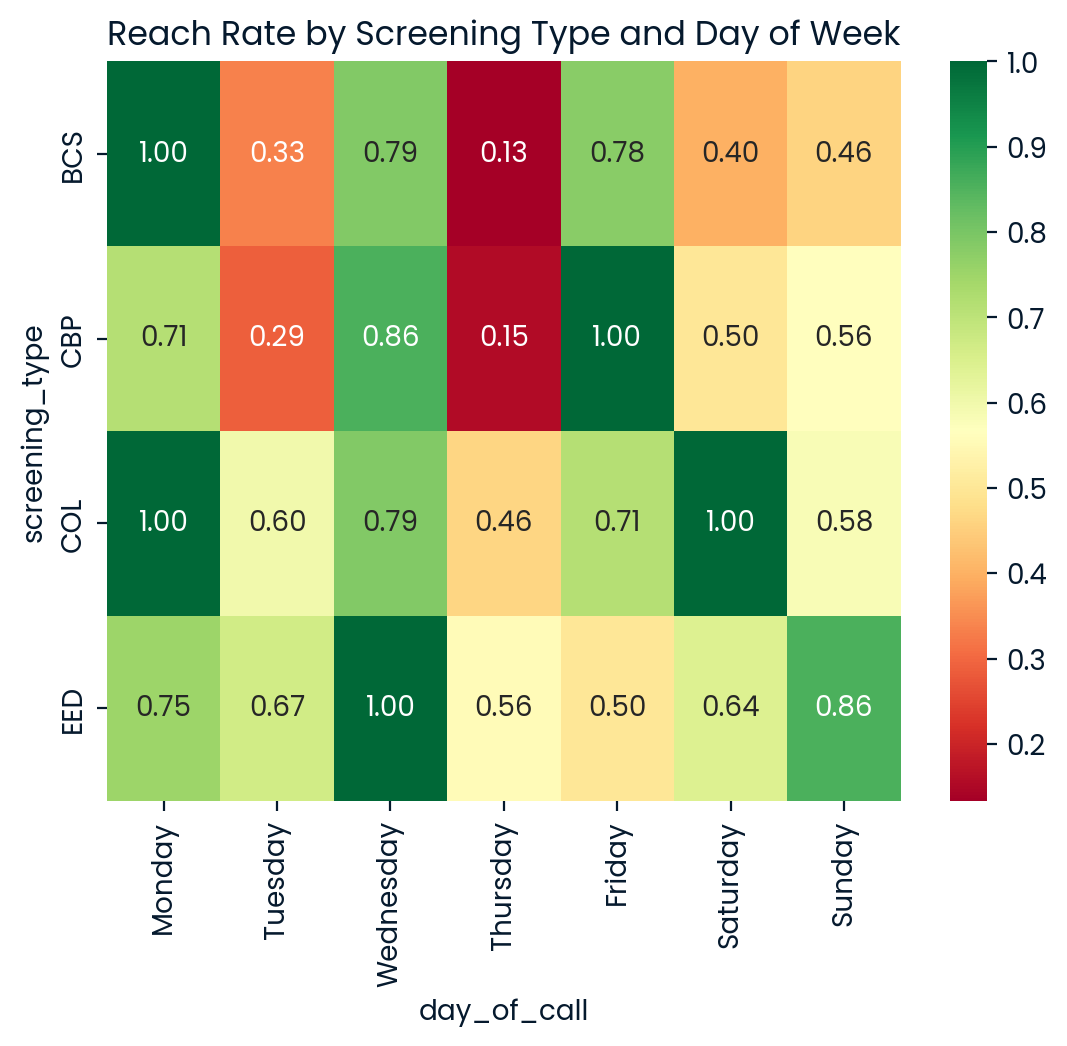

             succ_calls  unsucc_calls  t_calls
day_of_call                                   
Monday                5             0        5
Tuesday               4             8       12
Wednesday            15             4       19
Thursday              2            13       15
Friday                7             2        9
Saturday              2             3        5
Sunday               12            14       26


In [25]:
#let's add several columns:
df['day_of_call']=df['latest_call_date'].dt.day_name()
df['day_of_screening']=df['screening_date'].dt.day_name()

#order the columns according to the actual order in the week:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['day_of_call'] = pd.Categorical(df['day_of_call'], categories=day_order, ordered=True)
df['day_of_screening']=pd.Categorical(df['day_of_screening'], categories=day_order, ordered=True)

# now any groupby or value_counts will follow weekday order
print('The distribution of calls among days')
print(df['day_of_call'].value_counts().sort_index())
#df['day_of_screening'].value_counts().sort_index()

df_days=df.groupby('day_of_call').agg(
    succ_calls=('reached_ind', 'sum'),
    t_calls=('reached_ind', 'count' ),
)
df_days['reach_rate']=df_days['succ_calls']/df_days['t_calls']
print(df_days)

#As groups are very different in amount of calls done, let's use chi-square for an independence test on the number of calls(successful, unsuccessful)
df_days['unsucc_calls'] = df_days['t_calls'] - df_days['succ_calls']
days_c_table=df_days[['succ_calls', 'unsucc_calls']]
print(days_c_table)

import numpy as np
from scipy.stats import chi2_contingency

chi2_days, p_days, dof_days, expected_days=chi2_contingency(days_c_table)
residuals_days=(days_c_table - expected_days)/np.sqrt(expected_days)

print(f'chi-2 square = {chi2_days:.3f}')
print(f'p-value = {p_days:.4f}')
print('residuals:')
print(residuals_days)

#Let's check the interaction between day of week and screening type and their affect on the reach rate:
import seaborn as sns
import matplotlib.pyplot as plt

df_clean=df.dropna(subset=['reached_ind'])
df_clean=df_clean[df_clean['screening_type']!='OMW']
print(df_clean.info())
df_clean['reached_ind']=df_clean['reached_ind'].astype(int)
pivot = df_clean.groupby(['screening_type', 'day_of_call'])['reached_ind'].mean().unstack()

sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn')
plt.title('Reach Rate by Screening Type and Day of Week')
plt.show()

#Possible factors affected the outreach quality in group of patients eligible for BCS: day of call:
df_clean_bcs=df_clean[df_clean['screening_type']=='BCS']
df_clean_bcs=df_clean_bcs.groupby('day_of_call').agg(
    succ_calls=('reached_ind', 'sum'),
    t_calls=('reached_ind', 'count' ),
)
df_clean_bcs['unsucc_calls']=df_clean_bcs['t_calls']-df_clean_bcs['succ_calls']
print(df_clean_bcs[['succ_calls', 'unsucc_calls', 't_calls']])

A Chi-square test of independence (χ² = 65.04, p < 0.0001) confirms that the day of the week when patients are contacted has a statistically significant effect on the reach rate.
Analysis of the standardised residuals identifies Thursday and Monday as the strongest contributors to this effect:

Thursday shows the largest deviation from expected values (residuals: succ_calls = -3.07, unsucc_calls = +4.12), indicating significantly fewer successful calls and more unsuccessful calls than expected. With only a 33.8% reach rate across 65 calls, Thursday is clearly the worst day for outreach.
Monday shows the opposite pattern (residuals: succ_calls = +2.11, unsucc_calls = -2.84), with a 86.4% reach rate, making it the most effective day for outreach. Both residuals cross the significance threshold of 2. ✅
Wednesday shows a similar positive pattern to Monday (reach rate 84.4%), with residuals just below the threshold of 2 (1.99 and -2.68), suggesting a strong but marginally significant trend.
Tuesday shows a negative trend (reach rate 44.4%) with residuals of -1.67 and +2.24 — the unsuccessful calls residual crosses the threshold, indicating more unsuccessful calls than expected.
Friday and Saturday show moderate positive reach rates (81.8% and 73.7%) but residuals below 2, so no statistically notable deviation.
Sunday has the highest call volume (131 calls) but a moderate reach rate of 59.5%, with residuals close to zero — performing broadly as expected.


Zooming into the heatmap for BCS specifically:

Thursday reach rate drops to just 13% — extremely low
Tuesday reach rate is 33% — also notably poor
Both align with the overall pattern but are more pronounced in BCS than other screening types

Total of 280 calls were successfull. This is: 64.37% out of all calls


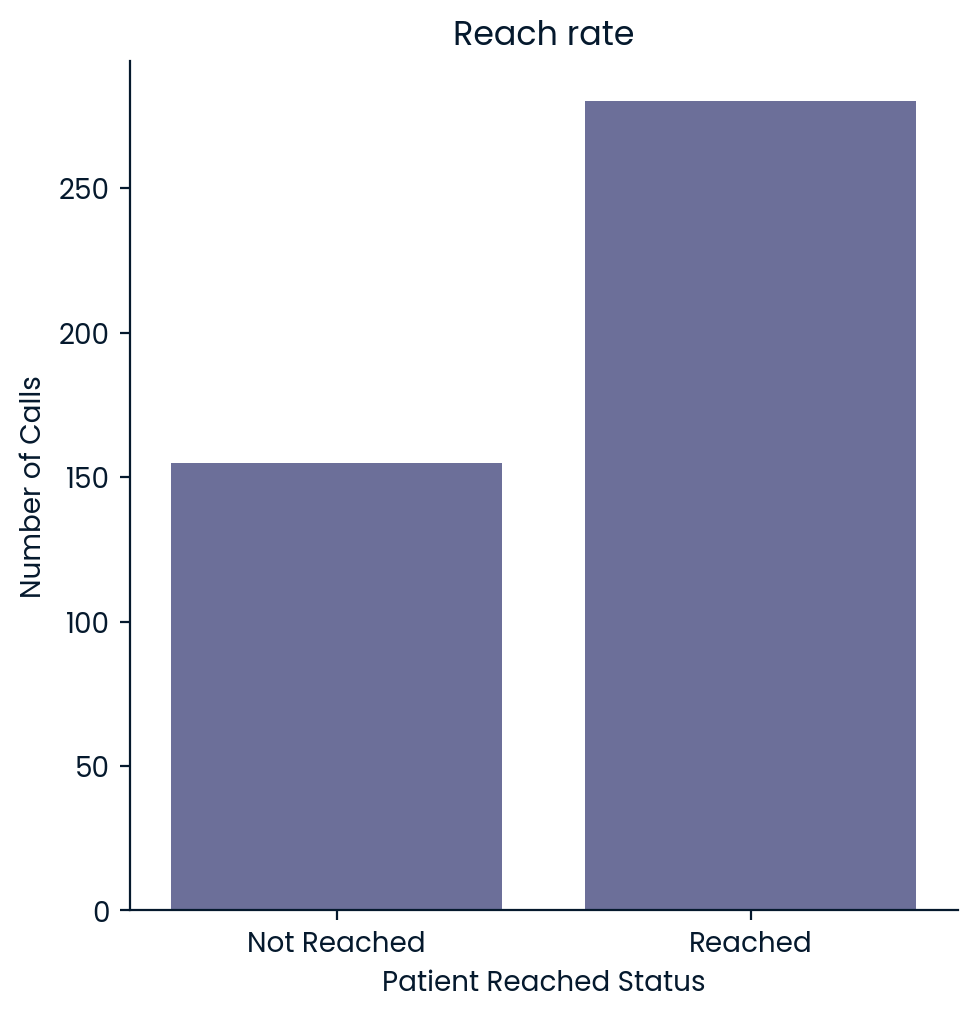

Total targeted patients 80
total reached patiets 56
Reach rate: 70.0% of all targeted patients were reached at least once


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

#Reach rate=successful calls/all calls*100

num_reached=df['reached_ind'].sum()
total_reached=df['reached_ind'].notna().sum()

per_reached= num_reached/total_reached*100
print(f"Total of {num_reached} calls were successfull. This is: {per_reached:.2f}% out of all calls")

#comparing reached(1) and non-reached(0):
sns.catplot(x='reached_ind', data=df[df['reached_ind'].notna()], kind='count')
plt.title('Reach rate')
plt.xlabel('Patient Reached Status')
plt.xticks([0, 1], ['Not Reached', 'Reached'])
plt.ylabel('Number of Calls')
plt.show()

#How many patients were reached?

#As patients could have several screening types eligible, let's check whether at least 1 time the patient was reached and whether this patient was targeted:

df_patient_reach = df.groupby('patient_id').agg(
    any_reached=('reached_ind', 'max'),
    any_targeted=('reached_ind', lambda x: x.notna().max())
    ).reset_index()
targeted_patients=df_patient_reach[df_patient_reach['any_targeted']==True]
total_targeted_patients = len(targeted_patients)
total_reached_patients=targeted_patients['any_reached'].sum()
print(f"Total targeted patients {total_targeted_patients}")
print(f'total reached patiets {total_reached_patients}')
reach_rate=total_reached_patients/total_targeted_patients*100
print(f'Reach rate: {reach_rate}% of all targeted patients were reached at least once')


                patients  scr_av  scr_per_p
screening_type                             
BCS                   43     109       2.53
CBP                   40     111       2.78
COL                   78     190       2.44
EED                   43     104       2.42
OMW                    6      13       2.17
                patients  succ_calls  t_calls  reach_rate  call_per_p
screening_type                                                       
BCS                   43          47       91        0.52        2.12
CBP                   40          61      102         0.6        2.55
COL                   78         105      150         0.7        1.92
EED                   43          60       81        0.74        1.88
OMW                    6           7       11        0.64        1.83


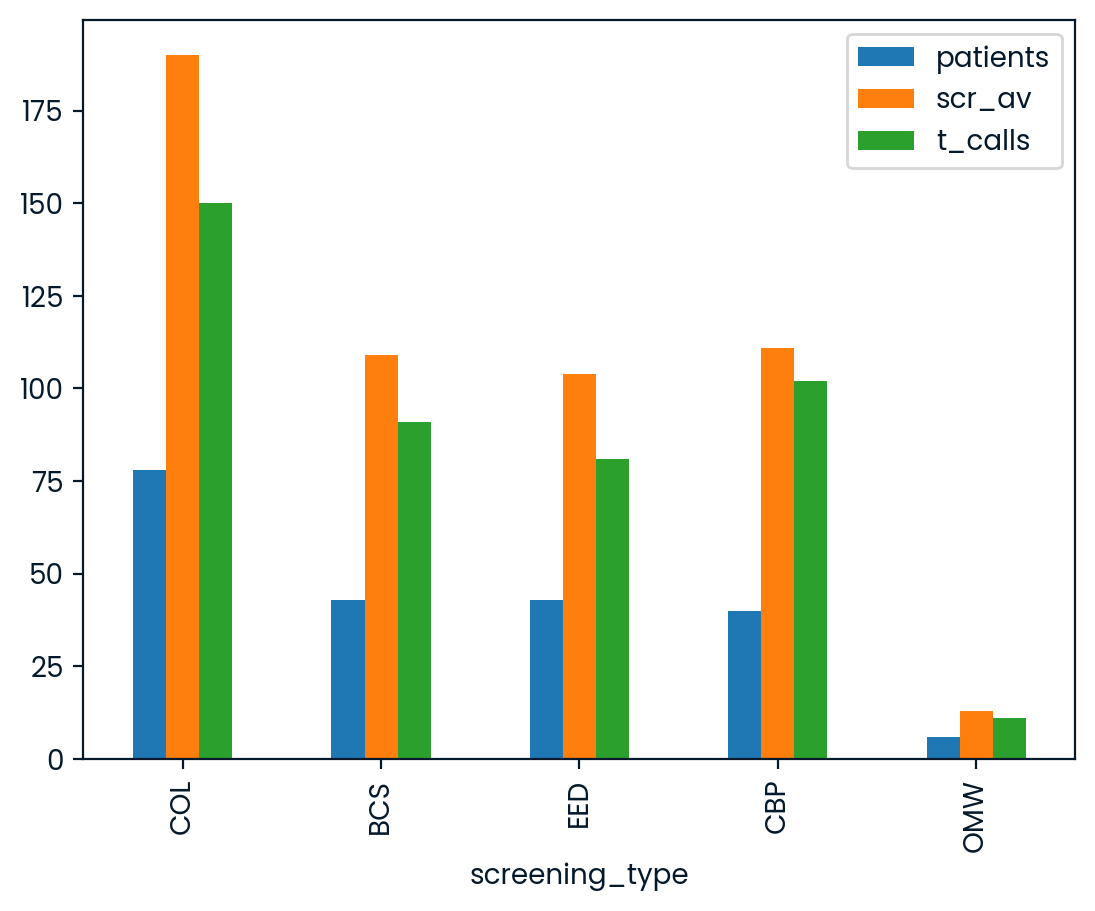

In [27]:
#How were patients targeted for the outreach program?

df_targeted=df.groupby('screening_type').agg(
    patients=('patient_id', 'nunique'),    #how many patients were targeted
    scr_av=('screening_completed_ind', 'count'), #all available screenings
    succ_calls=('reached_ind', 'sum'), #how many calls were successfull
    t_calls=('reached_ind', 'count') #total calls
)
df_targeted['scr_per_p'] = df_targeted['scr_av']/df_targeted['patients']
df_targeted['reach_rate'] = df_targeted['succ_calls']/df_targeted['t_calls']
df_targeted['call_per_p'] =df_targeted['t_calls']/df_targeted['patients']

pd.set_option('display.max_columns', None)
print(df_targeted[['patients', 'scr_av', 'scr_per_p']].round(2))
print(df_targeted[['patients', 'succ_calls', 't_calls', 'reach_rate', 'call_per_p']].round(2))
#Let's draw a histogram
import matplotlib.pyplot as plt
df_targeted_sorted=df_targeted[['patients', 'scr_av', 't_calls']].sort_values(by='patients', ascending=False)

df_targeted_sorted.plot(kind='bar', color=plt.get_cmap('tab10').colors)
plt.show()


The patients were assigned to different screening types in different proportions: the most significant group consists of 78 patients for colorectal cancer (COL), which is approximately twice as large as the three other groups — bowel cancer (BCS), controlling high blood pressure (CBP), and early elective delivery prevention (EED), each containing around 40 patients. There are only 6 patients in the osteoporosis management in women (OMW) group, which is notably small and may limit the reliability of any conclusions drawn from this group.
These imbalances in group sizes can significantly affect the compliance rate and patient behaviour. For example, cancer-related screenings tend to generate higher levels of patient anxiety, which may influence compliance differently compared to non-cancer screenings.
We also observe that the number of available screenings per patient varies across groups, ranging from approximately 2.17 to 2.78 screenings per patient.
It is also noteworthy that groups with a higher reach rate tend to have fewer calls per person (call_per_p), however this pattern requires further statistical testing before drawing conclusions.

In [28]:
# Let's check the statistical significance of reach rate (successful calls out of total calls) by every screening type:
# As there are only 6 patients in OMW group let's replace them from analysis right now and focus only on 4 types of screening.
df_no_omw=df_targeted.loc[df_targeted.index!='OMW']

#As groups are very different in amount of calls done and patients, let's use chi-square for independence test on the number of calls(successful, unsuccessful)
df_no_omw['unsucc_calls'] = df_no_omw['t_calls'] - df_no_omw['succ_calls']
no_omw_c_table=df_no_omw[['succ_calls', 'unsucc_calls']]
print(no_omw_c_table)

import numpy as np
from scipy.stats import chi2_contingency
chi2_no_omw, p_no_omw, dof_no_omw, expected_no_omw=chi2_contingency(no_omw_c_table)
residuals_no_omw=(no_omw_c_table - expected_no_omw)/np.sqrt(expected_no_omw)

print(f'chi-2 square = {chi2_no_omw:.3f}')
print(f'p-value = {p_no_omw:.4f}')
print('residuals:')
print(residuals_no_omw)

#As BSC reach rate is underperforming, let's check the days between later.


                succ_calls  unsucc_calls
screening_type                          
BCS                     47            44
CBP                     61            41
COL                    105            45
EED                     60            21
chi-2 square = 12.750
p-value = 0.0052
residuals:
                succ_calls  unsucc_calls
screening_type                          
BCS              -1.514393      2.036252
CBP              -0.576819       0.77559
COL               0.856758     -1.151997
EED               1.086541     -1.460962


To evaluate whether the reach rate differed significantly across screening types, a Chi-square test of independence was applied to the contingency table of successful and unsuccessful calls per screening type. This test was chosen because the outcome variable (reached/not reached) is binary, and we are comparing proportions across multiple independent groups with unequal sample sizes. The OMW group was excluded from this analysis due to an insufficient sample size (n=6), which violates the Chi-square assumption of at least 5 observations per cell.
The test returned a chi-square statistic of 12.75 and a p-value of 0.0052, which is well below the 0.05 significance threshold. This indicates that the differences in reach rate across screening types are statistically significant and are unlikely to be due to chance.
To identify which screening types contributed most to this result, standardised residuals were analysed. Residuals with an absolute value above 2 are considered statistically notable. The analysis revealed two main contributors:

BCS (Bowel Cancer Screening) showed fewer successful calls and more unsuccessful calls than expected, indicating a consistently lower-than-average reach rate. This group is the most problematic from an outreach perspective and may require a revised contact strategy. Let's check the days between later.
EED (Early Elective Delivery) showed the opposite pattern — more successful calls and fewer unsuccessful calls than expected, indicating a higher-than-average reach rate. This group responds well to the current outreach approach. Keep in mind this is just weak trend, need more data.

CBP and COL showed residuals close to zero, suggesting their reach rates are broadly in line with the overall average and do not deviate significantly from what would be expected.

patient_id       80
num_elligible    80
num_completed    80
dtype: int64
                patient_id  num_elligible  num_completed  fully_compliant
0   1131271556980622437867              8              4            False
1   1166895594582572044138              8              4            False
2   1243850413902711866862              1              1             True
3   1250609583524067741983              4              2            False
4   1335234766591311400435             19             10            False
..                     ...            ...            ...              ...
75  8932289453067547503801              2              1            False
76  9176170109115082315770              2              1            False
77  9386122047872841092588             12              6            False
78  9698231037659712908589              4              4             True
79  9797045826561842359199              2              1            False

[80 rows x 4 columns]
Number of Fully-

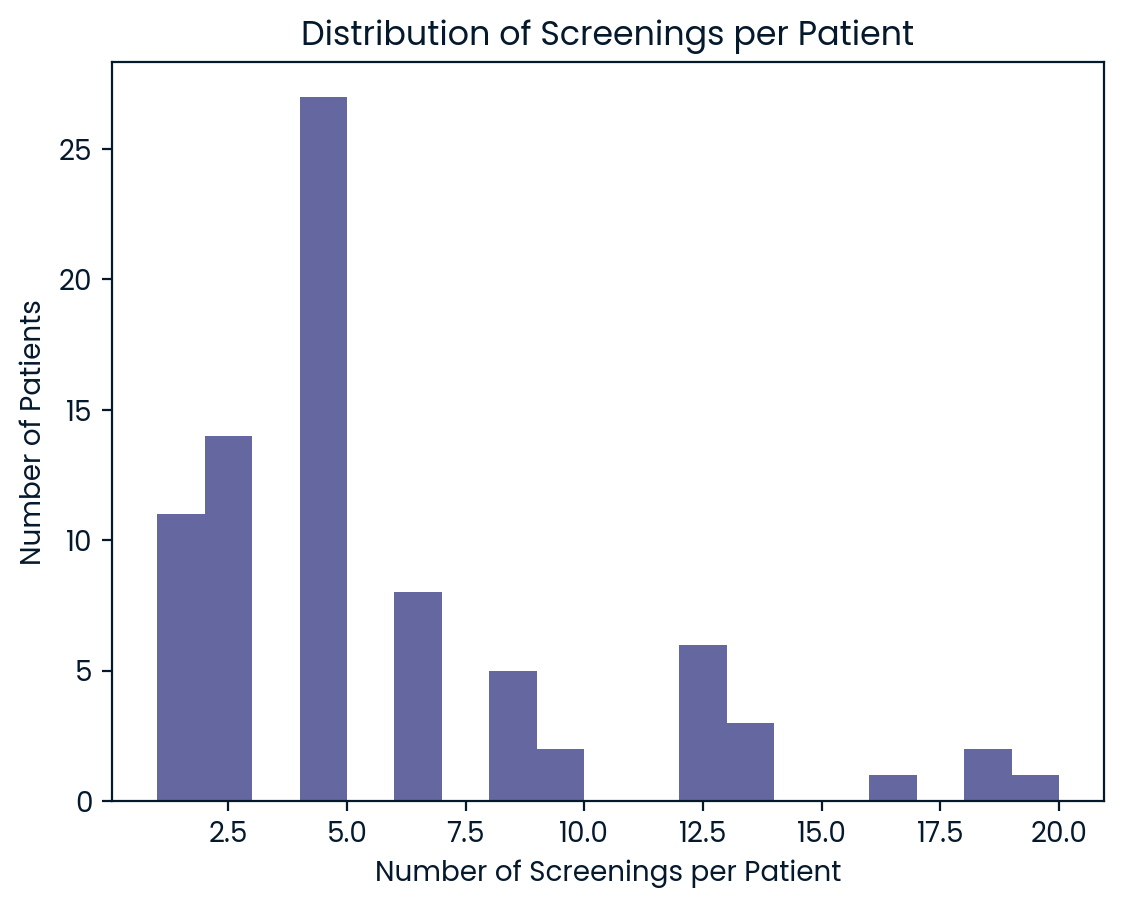

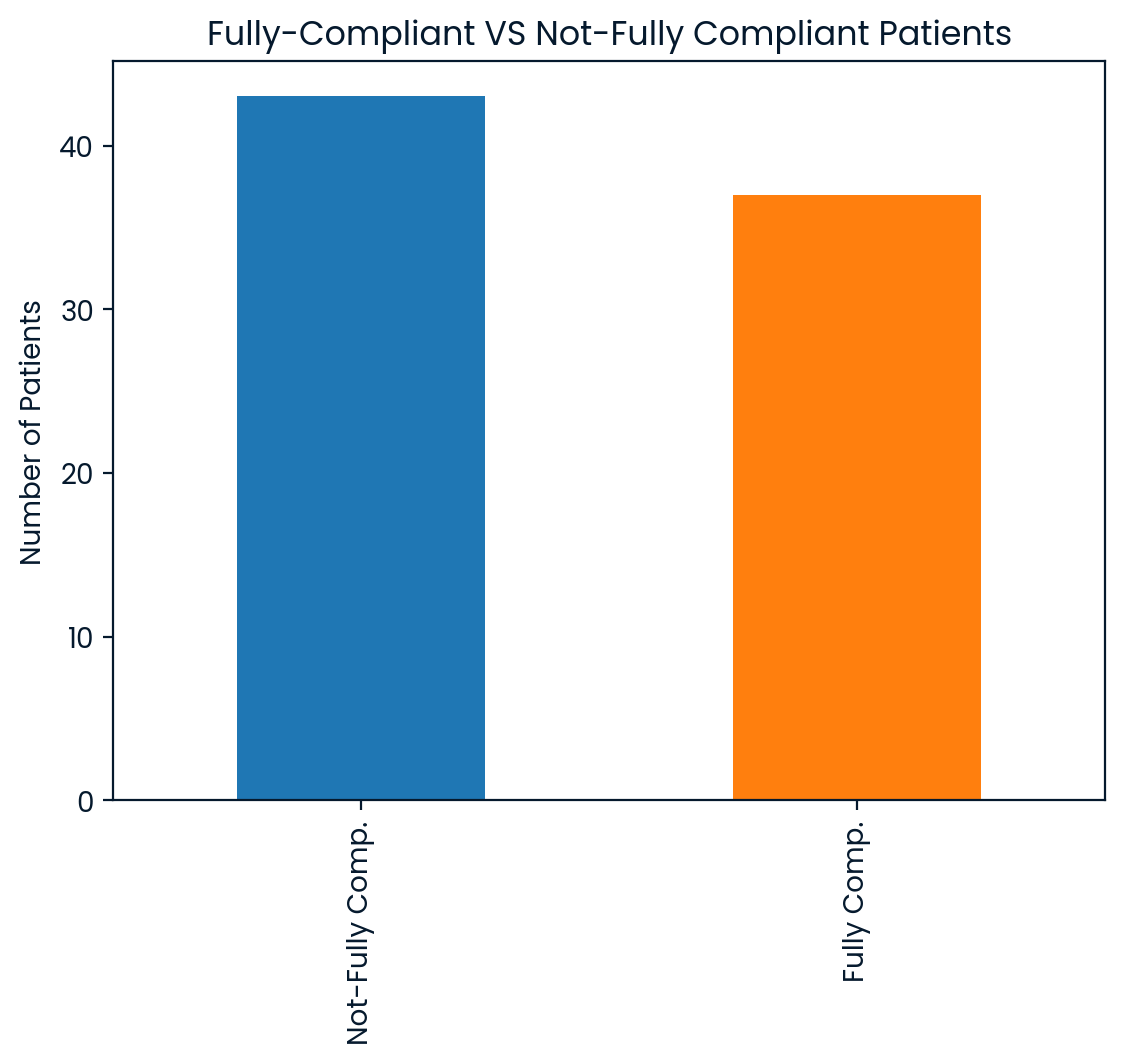

Screening period: 2024-02-04 00:00:00 to 2025-01-13 00:00:00
Call period: 2024-01-01 00:00:00 to 2024-12-16 00:00:00
The cases where the screening_date was earlier than the latest_call_date
Empty DataFrame
Columns: [patient_id, screening_type, screening_completed_ind, latest_call_date, reached_ind, screening_date, day_of_call, day_of_screening]
Index: []
 there are 18 patients who were assigned and didn't complete the same screening at least 2 times
overall there were 41 cases when patient was assigned and didn't complete the same screening type
                patient_id screening_type  count
0   1131271556980622437867            CBP      2
1   1131271556980622437867            EED      2
2   1166895594582572044138            CBP      2
3   1166895594582572044138            EED      2
6   1335234766591311400435            BCS      3
7   1335234766591311400435            CBP      3
8   1335234766591311400435            COL      3
15  2168305126439284798651            BCS      2
16  216

In [29]:
#Aggregating information on the patient level

df=df.dropna(subset='reached_ind')

df_patient=df.groupby('patient_id').agg(
    num_elligible=('screening_completed_ind', 'count'),
    num_completed=('screening_completed_ind', 'sum')
).reset_index()

print(df_patient.notna().sum())

#Creating a compliance flag

df_patient['fully_compliant']=df_patient['num_completed']==df_patient['num_elligible'] 
print(df_patient)
print('Number of Fully-compliant:')
print(df_patient['fully_compliant'].sum())
print('Total number targeted:')
print(df_patient['fully_compliant'].count())
print(df_patient['num_elligible'].describe())
print(f"75% of patients have up to {df_patient['num_elligible'].quantile(0.75)} eligible screening")

#Screenings per Patient eligible

import matplotlib.pyplot as plt
plt.hist(df_patient['num_elligible'], bins=range(1, df_patient['num_elligible'].max()+2))
plt.title('Distribution of Screenings per Patient')
plt.xlabel('Number of Screenings per Patient')
plt.ylabel('Number of Patients')
plt.show()

#Fully-Compliant VS Not-Fully Compliant Patients

df_patient['fully_compliant'].value_counts().plot(kind='bar', color=plt.get_cmap('tab10').colors)
plt.xticks([0, 1], ['Not-Fully Comp.', 'Fully Comp.'], rotation=90)
plt.ylabel('Number of Patients')
plt.title('Fully-Compliant VS Not-Fully Compliant Patients')
plt.show()

#Let's check the period of data collection:
print("Screening period:", df['screening_date'].min(), "to", df['screening_date'].max())

print("Call period:", df['latest_call_date'].min(), "to", df['latest_call_date'].max())
print("The cases where the screening_date was earlier than the latest_call_date")
print(df[df['screening_date'] < df['latest_call_date']])

#Let's check if the same patients were assigned to the same screenings several times and didn't complete them:
incomplete_df=df[df['screening_completed_ind'] ==0]
duplicates=incomplete_df.groupby(['patient_id', 'screening_type'])['screening_completed_ind'].count()
duplicates=duplicates.reset_index(name='count')
duplicates=duplicates[duplicates['count']>1]
print(f" there are {duplicates['patient_id'].nunique()} patients who were assigned and didn't complete the same screening at least 2 times")
print(f"overall there were {len(duplicates)} cases when patient was assigned and didn't complete the same screening type")
print(duplicates)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   patient_id     80 non-null     object
 1   num_elligible  80 non-null     int64 
 2   num_completed  80 non-null     Int64 
dtypes: Int64(1), int64(1), object(1)
memory usage: 2.1+ KB
None
patient_id       0
num_elligible    0
num_completed    0
dtype: int64
0.736359930274404
count    80
sum      37
Name: fully_compliant, dtype: int64


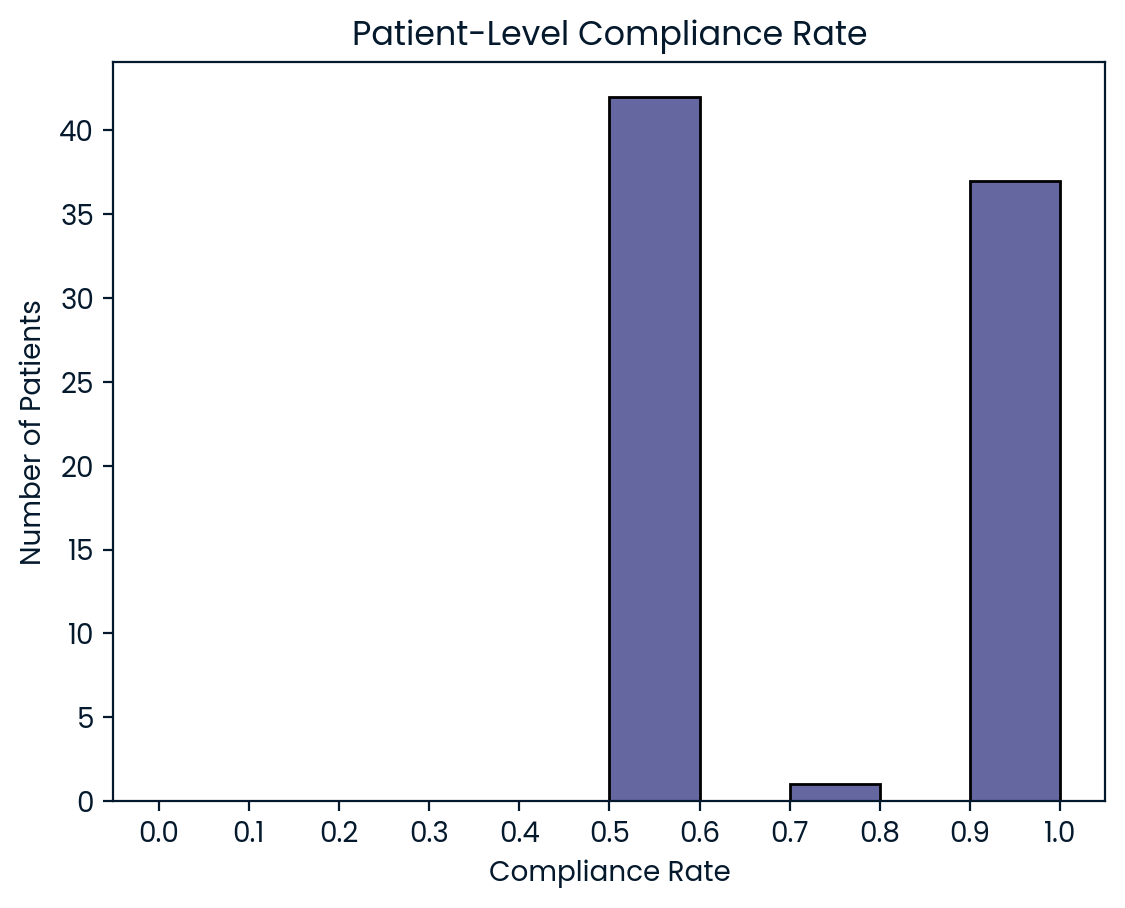

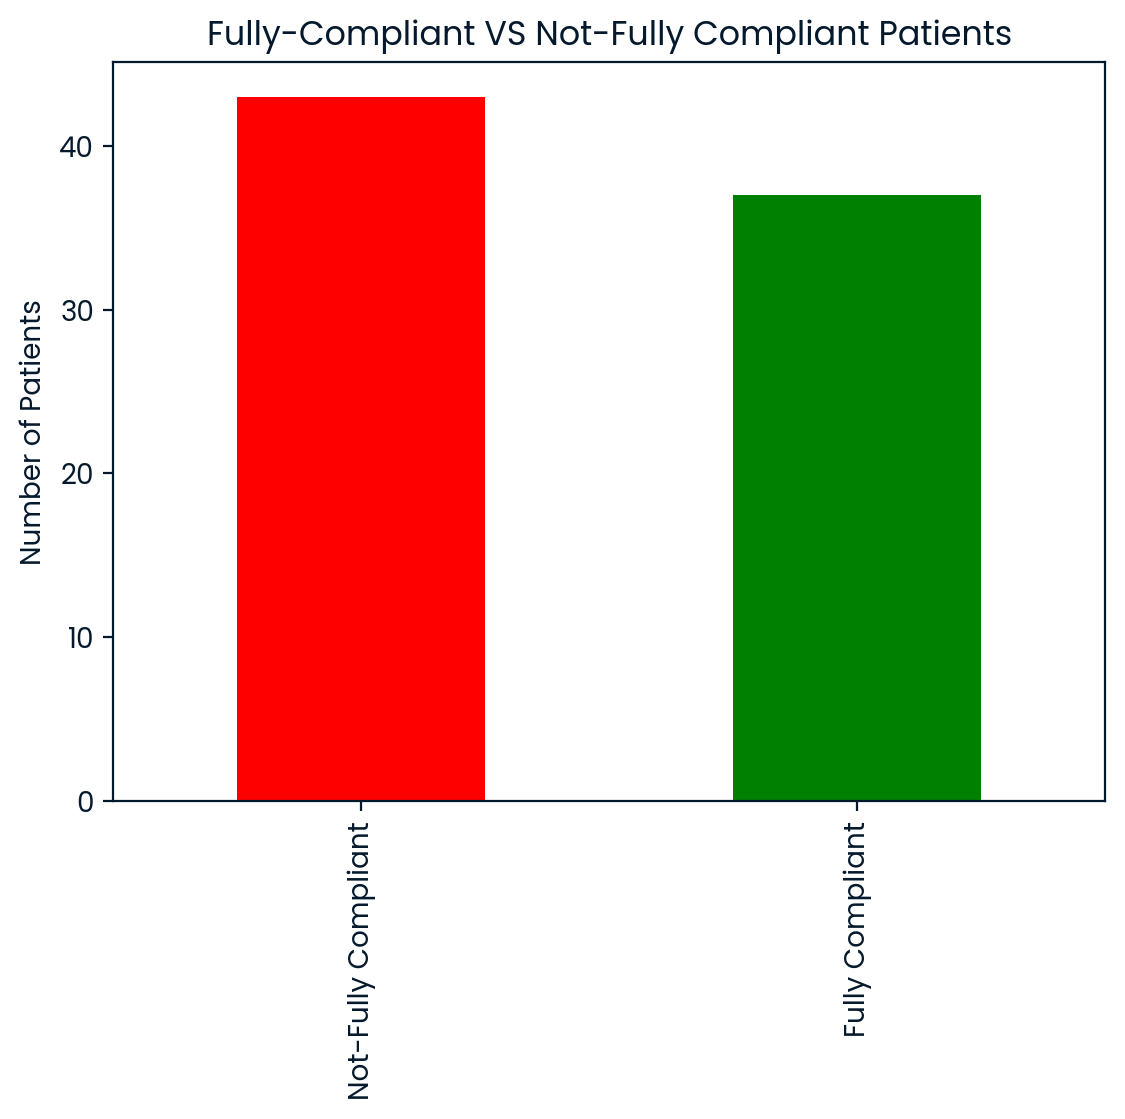

Fully comliant/N-fully cmpliant patients by screening type
                fcompliant  nf_patients
screening_type                         
BCS                     15           17
CBP                     13           20
COL                     24           27
EED                      9           18
OMW                      2            2
Standardized residuals
               Fully compliant Not fully compliant
screening_type                                    
BCS                   0.347183           -0.300669
CBP                  -0.303895            0.263181
COL                   0.458349           -0.396942
EED                  -0.755929            0.654654
OMW                   0.218218           -0.188982
chi-2 square = 1.824
p-value = 0.7682
residuals_df:
               Fully compliant Not fully compliant
screening_type                                    
BCS                   0.347183           -0.300669
CBP                  -0.303895            0.263181
COL                   0.4

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, mannwhitneyu
from pingouin import compute_effsize


#Preparing a correct aggregation on the patient-level:
df_patient_correct=df.groupby('patient_id').agg(
    num_elligible=('screening_type', 'count'),
    num_completed=('screening_completed_ind', 'sum')
).reset_index()
print(df_patient_correct.info())
print(df_patient_correct.isna().sum())

#Compliance metrics: compliance rate and the number of fully-compliant patients:
df_patient_correct['compliance_rate']=df_patient_correct['num_completed']/df_patient_correct['num_elligible']
print(df_patient_correct['compliance_rate'].mean())

df_patient_correct['fully_compliant'] = df_patient_correct['num_completed'] == df_patient_correct['num_elligible']
print(df_patient_correct['fully_compliant'].agg(['count', 'sum']))

#Plots with gen info about compliance rate and number of fully-compliant patients:
plt.hist(df_patient_correct['compliance_rate'], bins=[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1], edgecolor='black')

plt.title('Patient-Level Compliance Rate')
plt.xlabel('Compliance Rate')
plt.xticks([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])
plt.ylabel('Number of Patients')
plt.show()

df_patient_correct['fully_compliant'].value_counts().plot(kind='bar', color=['red', 'green'])

plt.xticks([0, 1], ['Not-Fully Compliant', 'Fully Compliant'])
plt.ylabel('Number of Patients')
plt.title('Fully-Compliant VS Not-Fully Compliant Patients')
plt.show()


#fully-compliant BY SCREENING TYPE
df_fcompliant_screening=df_patient_screening.groupby('screening_type').agg(
    n_patients=('fully_compliant', 'count'), fcompliant=('fully_compliant', 'sum')
)
df_fcompliant_screening['nf_patients']=(df_fcompliant_screening['n_patients']-df_fcompliant_screening['fcompliant'])
df_fcompliant_screening=df_fcompliant_screening.drop(columns='n_patients')
print('Fully comliant/N-fully cmpliant patients by screening type')
print(df_fcompliant_screening)


import numpy as np
from scipy.stats import chi2_contingency
fcompliant_contingency = df_fcompliant_screening[
    ['fcompliant', 'nf_patients']
].values
chi2_f, p_f, dof_f, expected_f=chi2_contingency(fcompliant_contingency)
residuals_f=(fcompliant_contingency - expected_f)/np.sqrt(expected_f)

residuals_df = pd.DataFrame(
    residuals_f,
    index=df_fcompliant_screening.index,
    columns=['Fully compliant', 'Not fully compliant']
)

print('Standardized residuals')
print(residuals_df)
print(f'chi-2 square = {chi2_f:.3f}')
print(f'p-value = {p_f:.4f}')
print('residuals_df:')
print(residuals_df)


#Chi-square by screening type
results_screening=[]
for screening in ['BCS', 'CBP', 'COL', 'EED']:
    subset = df_patient_screening[df_patient_screening['screening_type'] == screening]
    
    reached=subset[subset['was_reached'] ==1]['fully_compliant']
    not_reached=subset[subset['was_reached'] ==0]['fully_compliant']
    fcompliant_table=np.array([
        [reached.sum(), len(reached) - reached.sum()],
        [not_reached.sum(), len(not_reached) - not_reached.sum()]
    ])
    chi2_stat, p_value, dof_3, expect = chi2_contingency(fcompliant_table)
    
    results_screening.append({
        'screening_type': screening,
        'chi2_stat': chi2_stat,
        'p_value': p_value
    })
    df_results_screening = pd.DataFrame(results_screening)
print('Fully-compliant patients between reached/not reached by screening type:')
print(df_results_screening)

There is no statistical difference between screening types in terms of amount of fully-compliant patients.
It supports the idea, that screening type doesn't affect the behaviour of the patients.
Also, there is no evidence that the outreach compaign affected the amount of fullly-compliant patients.

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, mannwhitneyu
from pingouin import compute_effsize

#Comparing compliance rate among not reached/reached BY SCREENING TYPE:

df_patient_screening=df.groupby(['patient_id', 'screening_type']).agg(
    num_elligible=('screening_type', 'count'),
    num_completed=('screening_completed_ind', 'sum'),
    was_reached=('reached_ind', 'max')
).reset_index()

print(df_patient_screening.head(5))

df_patient_screening['compliance_rate']=df_patient_screening['num_completed']/df_patient_screening['num_elligible']
df_patient_screening['fully_compliant'] = df_patient_screening['num_completed'] == df_patient_screening['num_elligible']
compliance_by_outreach_by_screening=df_patient_screening.groupby(['was_reached', 'screening_type'])['compliance_rate'].mean()

results=[]
bonferroni_alpha = 0.05 / 4

for screening in ['BCS', 'CBP', 'COL', 'EED']:
    sub=df_patient_screening[df_patient_screening['screening_type'] == screening]
    
    g0 = (
    sub[sub['was_reached'] == False]['compliance_rate']
    .astype('float64')
    .to_numpy()
)

    g1 = (
    sub[sub['was_reached'] == True]['compliance_rate']
    .astype('float64')
    .to_numpy()
)

hedges = compute_effsize(g1, g0, eftype='hedges')
    
results.append({
        'screening_type': screening,
        'mean_not_reached': g0.mean(),
        'mean_reached': g1.mean(),
        'mean_diff': g1.mean() - g0.mean(),
        'mann_whitney_stat': stat,
        'p_value': p,
        'p_corrected': min(p * 4, 1.0),  # Bonferroni correction
        'significant': p < bonferroni_alpha,
        'hedges_g': hedges,
        'n_not_reached': len(g0),
        'n_reached': len(g1)
    })

results_df = pd.DataFrame(results)
print(results_df[['screening_type', 'mean_not_reached', 'mean_reached', 
                   'mean_diff', 'p_value', 'p_corrected', 'significant', 
                   'hedges_g', 'n_not_reached', 'n_reached']].round(4))
print(df.groupby(['patient_id', 'screening_type']).size().describe())

               patient_id screening_type  num_elligible  num_completed  \
0  1131271556980622437867            CBP              4              2   
1  1131271556980622437867            EED              4              2   
2  1166895594582572044138            CBP              4              2   
3  1166895594582572044138            EED              4              2   
4  1243850413902711866862            BCS              1              1   

   was_reached  
0         True  
1         True  
2        False  
3        False  
4        False  
  screening_type  mean_not_reached  mean_reached  mean_diff  p_value  \
0            EED            0.7143          0.65    -0.0643   0.5901   

   p_corrected  significant  hedges_g  n_not_reached  n_reached  
0          1.0        False   -0.2563              7         20  
count    147.000000
mean       2.959184
std        1.475264
min        1.000000
25%        2.000000
50%        2.000000
75%        4.000000
max        7.000000
dtype: float64


Also, no evidence of significant difference between outreached/not-outreached patients in terms of their compliance rate. What is important to mention that the distribution of compliance rate is not-normal, bimodal with 2 peaks and this could reflect the situation where decent part of the sample was asigned several times for the same screening type and didn't finish them.

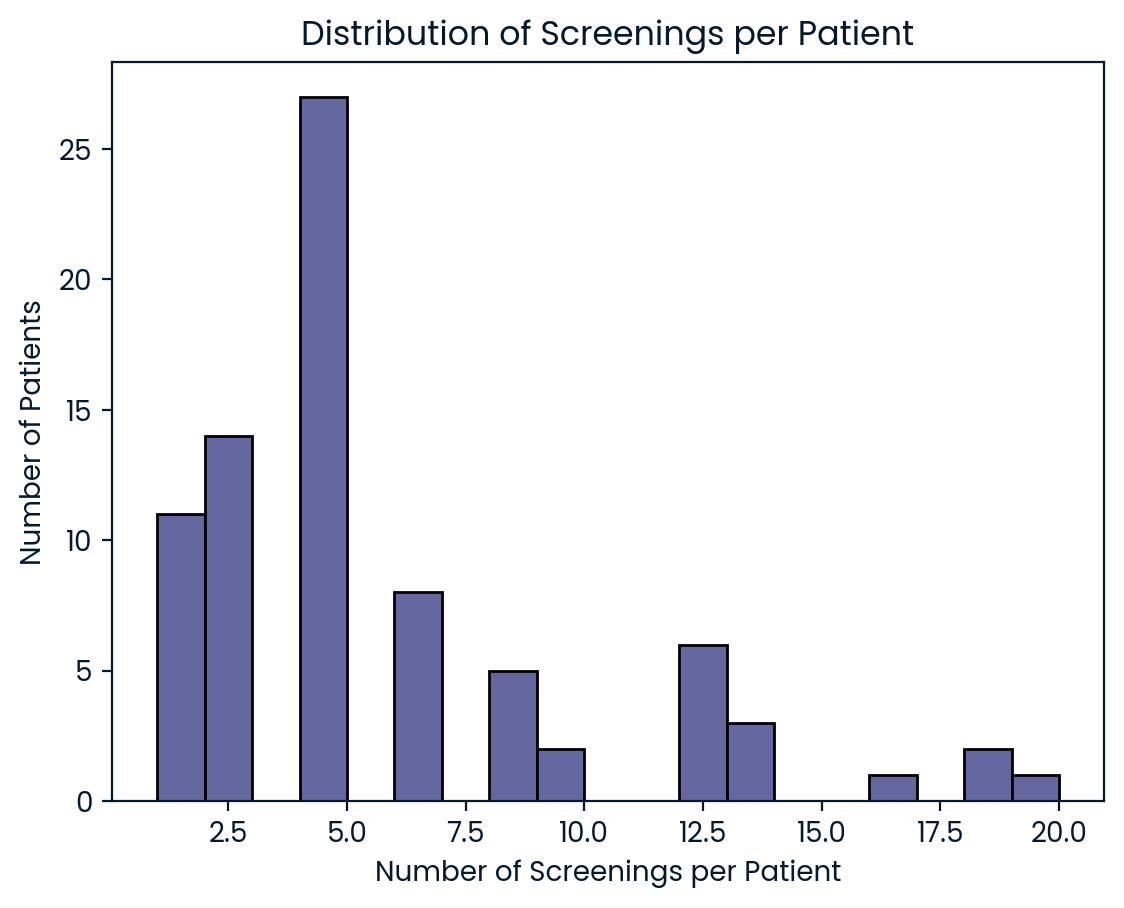

number_unique_types
1    27
2    40
3    12
4     1
Name: patient_id, dtype: int64
   number_unique_types  compliance_rate  fully_compliant  num_elligible
0                    1            0.815             0.63          1.815
1                    2            0.709              0.4          5.500
2                    3             0.63             0.25         12.500
3                    4              1.0              1.0         16.000


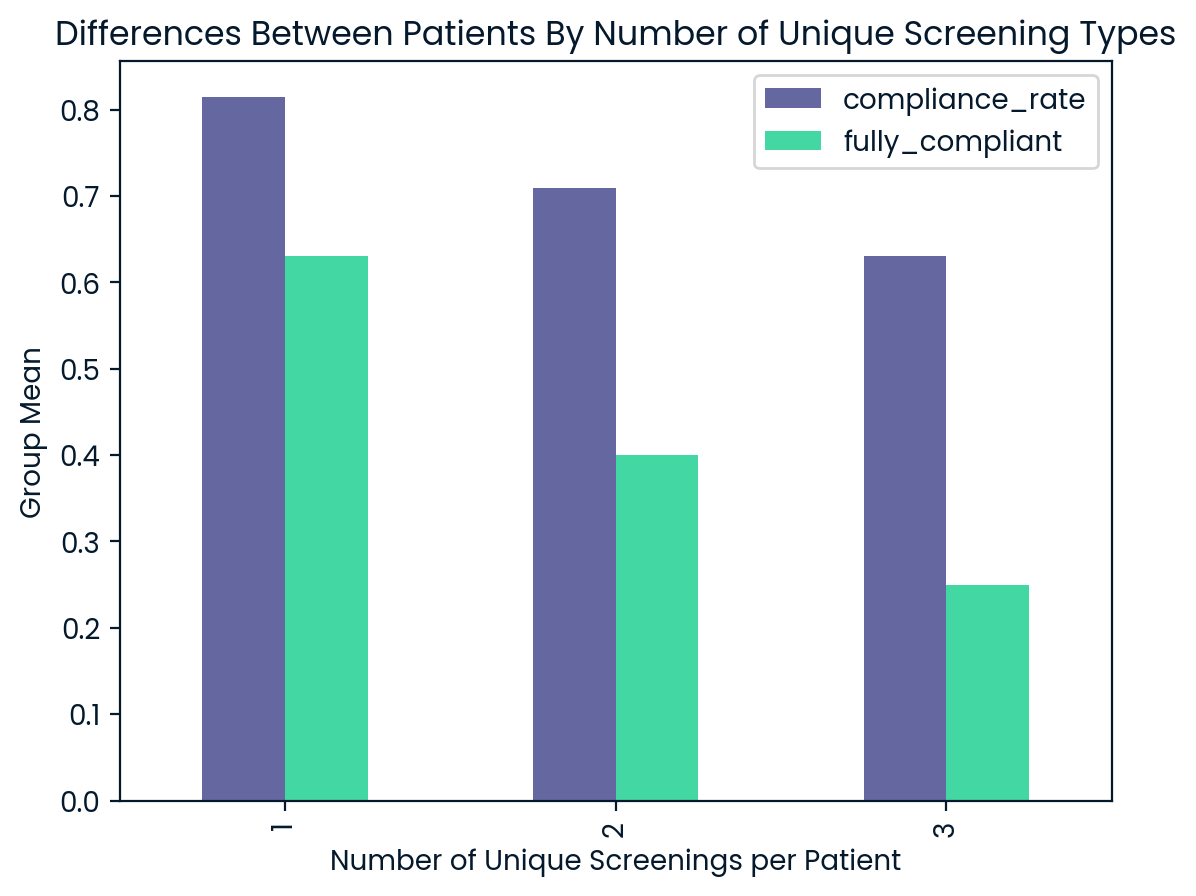

Kruskal-Wallis for compliance rate: statistic=3.932, p-value=0.140 
Kruskal-Wallis for num_elligible: statistic=58.756, p=0.000
Kruskal-Wallis for rate of fully compliant patients: statistic=5.766, p-value=0.056 


In [32]:
#Screenings per Patient eligible and the compliance rate/fully compliant patients
plt.hist(df_patient_correct['num_elligible'], bins=range(1, df_patient_correct['num_elligible'].max()+2), edgecolor='black')
plt.title('Distribution of Screenings per Patient')
plt.xlabel('Number of Screenings per Patient')
plt.ylabel('Number of Patients')
plt.show()

# Preparing a table with eligible unique screenings for each patient_id:
patient_unique=df.groupby('patient_id')['screening_type'].nunique().reset_index()
patient_unique.columns=['patient_id', 'number_unique_types']
print(patient_unique.groupby('number_unique_types')['patient_id'].count())

df_analysis=df_patient_correct.merge(patient_unique, on='patient_id', how='left')

summary = df_analysis.groupby('number_unique_types').agg({
    'compliance_rate': 'mean', 
    'fully_compliant': 'mean',  
    'num_elligible': 'mean'
}).round(3).reset_index()

print(summary)
summary_plot=summary[summary['number_unique_types'] != 4]
summary_plot.plot(
    x='number_unique_types',
    y=['compliance_rate', 'fully_compliant'],
    kind='bar'
)
plt.title('Differences Between Patients By Number of Unique Screening Types')
plt.xlabel('Number of Unique Screenings per Patient')
plt.ylabel('Group Mean')
plt.show()

#Statistical criteria of difference(with replacement of 4th goupr, as there is only 1 person):
import numpy as np
from scipy.stats import kruskal

group1=df_analysis[df_analysis['number_unique_types'] == 1]['compliance_rate']
group2=df_analysis[df_analysis['number_unique_types'] == 2]['compliance_rate']
group3=df_analysis[df_analysis['number_unique_types'] == 3]['compliance_rate']

stat, p_v =kruskal(group1, group2, group3)
print(f'Kruskal-Wallis for compliance rate: statistic={stat:.3f}, p-value={p_v:.3f} ')
#Patients eligible for more unique screening types have significantly lower compliance rates than patients eligible for just 1 type.

#The difference in the number of eligible tests among patients with different amounts of unique screening types:
group1 = df_analysis[df_analysis['number_unique_types'] == 1]['num_elligible']
group2 = df_analysis[df_analysis['number_unique_types'] == 2]['num_elligible'] 
group3 = df_analysis[df_analysis['number_unique_types'] == 3]['num_elligible']

stat, p = kruskal(group1, group2, group3)
print(f"Kruskal-Wallis for num_elligible: statistic={stat:.3f}, p={p:.3f}")
#Patients eligible for more unique screening types receive significantly more total screening opportunities than single-type patients. This is not random - it's a systematic pattern. Keeping in mind that there are many duplicate screenings that weren't finished by patients, maybe we need to revise the strategy of screening assignment.

group1=df_analysis[df_analysis['number_unique_types'] == 1]['fully_compliant']
group2=df_analysis[df_analysis['number_unique_types'] == 2]['fully_compliant']
group3=df_analysis[df_analysis['number_unique_types'] == 3]['fully_compliant']

st, p_v1 =kruskal(group1, group2, group3)
print(f'Kruskal-Wallis for rate of fully compliant patients: statistic={st:.3f}, p-value={p_v1:.3f} ')

We see high level of interaction between the amount of unique sceenings that were assigned and the amount of overall elligible screenings meaning that the same patients were assigned for different screenings at the same time with several dates of visits within the same type of screening. This could provoke the 'overwhelmness' with different screeings and decrease the level of compliance. We also see the tendency in decreasing the level of fully compliant patients with adding every new type of screening. This tendency doesn't reach the p-level less than 5 (0.056) so it is now at the level of tendency. It is worth to repeat the experiment with better design and measure the difference again.

In [33]:
#Were patients more likely to get their screenings done (i.e. become compliant) after we reached them compared to patients we did not reach? (Screening - level Analysis)

screening_types = ['BCS', 'CBP', 'COL', 'EED']
bonferroni_alpha = 0.05 / len(screening_types)

results_screening = []

for screening in screening_types:
    
    # use original df, not df_patient_screening
    subset = df[df['screening_type'] == screening]
    
    contingency = pd.crosstab(
        subset['reached_ind'],
        subset['screening_completed_ind']
    )
    contingency.index = ['Not reached', 'Reached']
    contingency.columns = ['Not compliant', 'Compliant']
    
    # check minimum cell count
    if (contingency < 5).any().any():
        print(f"{screening}: cell count below 5, skipping")
        continue
    
    chi2_stat, p_value, dof, expected = chi2_contingency(contingency)
    residuals = (contingency - expected) / np.sqrt(expected)
    
    # compliance rates
    compliance_rates = contingency['Compliant'] / contingency.sum(axis=1)
    
    results_screening.append({
        'screening_type': screening,
        'fully_compliant_not_reached': compliance_rates['Not reached'],
        'fully_compliant_reached': compliance_rates['Reached'],
        'uplift': compliance_rates['Reached'] - compliance_rates['Not reached'],
        'chi2': chi2_stat,
        'p_value': p_value,
        'p_corrected': min(p_value * len(screening_types), 1.0),
        'significant': p_value < bonferroni_alpha
    })
    
    print(f"\n{screening}:")
    print(contingency)
    print(f"\nResiduals:\n{residuals}")


df_results_screening = pd.DataFrame(results_screening)
print("\nSummary:")
print(df_results_screening.round(4))


BCS:
             Not compliant  Compliant
Not reached             15         29
Reached                 14         33

Residuals:
             Not compliant  Compliant
Not reached       0.261182  -0.178627
Reached          -0.252709   0.172832

CBP:
             Not compliant  Compliant
Not reached             14         27
Reached                 19         42

Residuals:
             Not compliant  Compliant
Not reached       0.201889  -0.139619
Reached          -0.165516   0.114465

COL:
             Not compliant  Compliant
Not reached             14         31
Reached                 32         73

Residuals:
             Not compliant  Compliant
Not reached       0.053838  -0.035806
Reached          -0.035245   0.023440

EED:
             Not compliant  Compliant
Not reached              6         15
Reached                 23         37

Residuals:
             Not compliant  Compliant
Not reached      -0.553801   0.413572
Reached           0.327633  -0.244673

Summary:
  scre

<class 'pandas.core.frame.DataFrame'>
Int64Index: 435 entries, 0 to 1986
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   patient_id               435 non-null    object        
 1   screening_type           435 non-null    object        
 2   screening_completed_ind  435 non-null    boolean       
 3   latest_call_date         435 non-null    datetime64[ns]
 4   reached_ind              435 non-null    boolean       
 5   screening_date           435 non-null    datetime64[ns]
 6   day_of_call              435 non-null    category      
 7   day_of_screening         435 non-null    category      
 8   days_between             435 non-null    int64         
 9   days_category            435 non-null    category      
dtypes: boolean(2), category(3), datetime64[ns](2), int64(1), object(2)
memory usage: 24.3+ KB
None


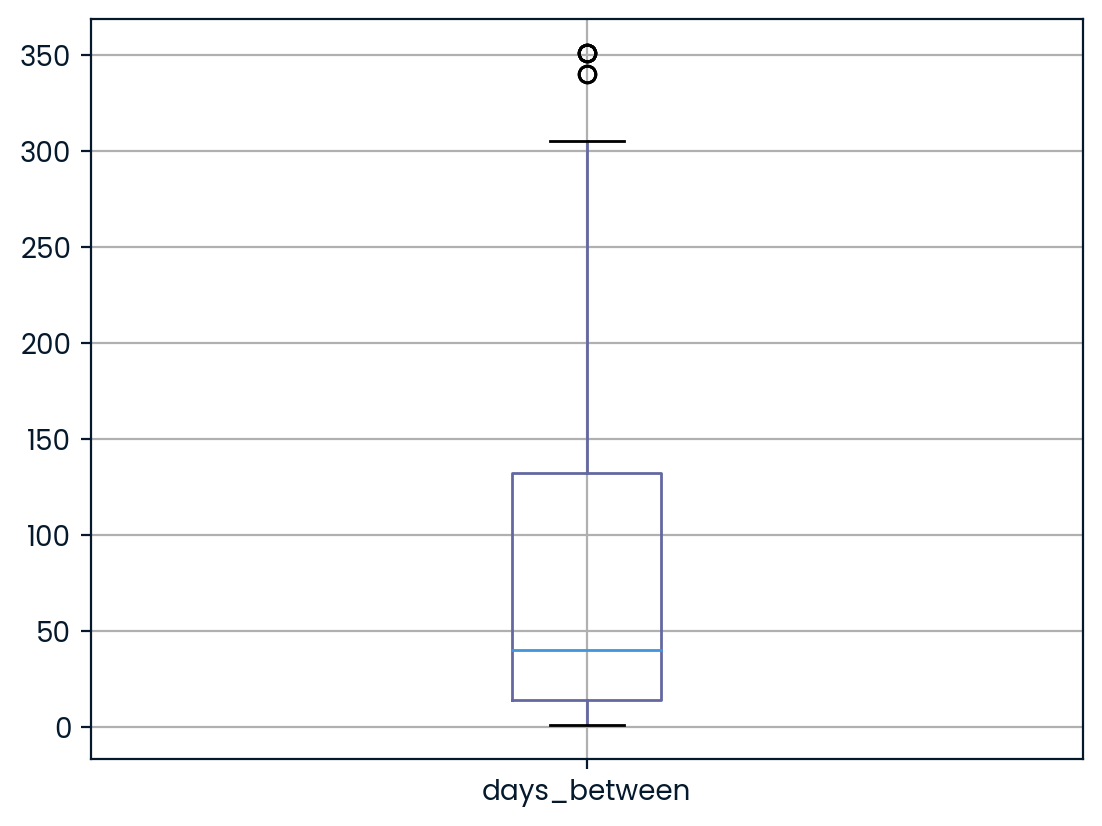

count    435.0
mean      82.6
std       89.7
min        1.0
25%       14.0
50%       40.0
75%      132.0
max      351.0
Name: days_between, dtype: float64


In [45]:
#The effect of date of the call before screening

#Let's calculate days between last call and the screening date for each screening
df['days_between'] = (df['screening_date'] - df['latest_call_date']).dt.days
df.dropna(subset=['days_between'], inplace=True)
df['days_between']=df['days_between'].astype(int)
print(df.info())

df.boxplot(column='days_between', grid=True)
plt.show()
print(df['days_between'].describe().round(1))


The majority of clients were contacted more than 1 month before the screening up to 150 days. It might be useful to focus on calls prior 1 month or less before the screening. In general patients tend to be more compliant if they're eligible for a screening.

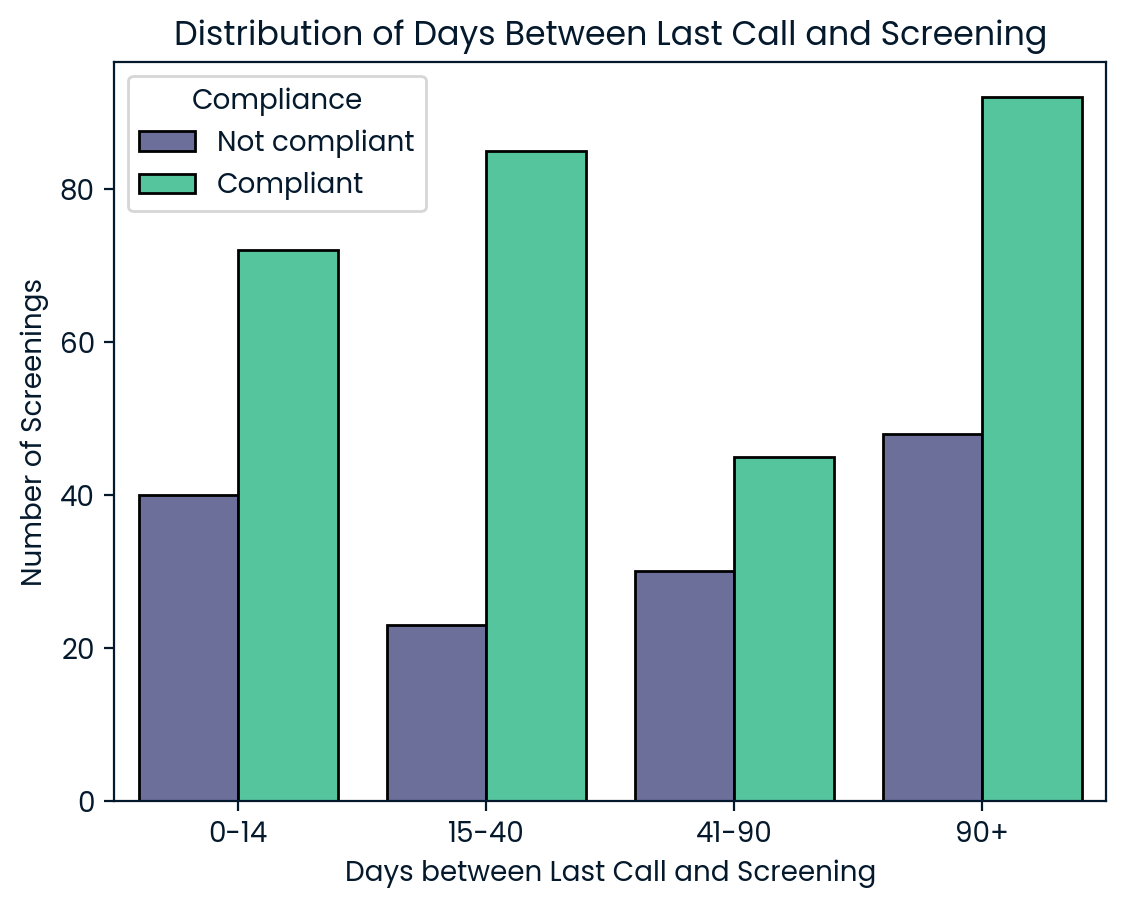

               Non Compliant  Compliant  All
days_category                               
0-14                      40         72  112
15-40                     23         85  108
41-90                     30         45   75
90+                       48         92  140
All                      141        294  435

Chi-square statistic: 8.844
p-value: 0.065
Degrees of freedom: 4

Residuals:
               Non Compliant  Compliant
days_category                          
0-14                0.613512  -0.424873
15-40              -2.029336   1.405367
41-90               1.153959  -0.799146
90+                 0.389033  -0.269415
All                 0.000000   0.000000

Compliance rates by day bin:
days_category
0-14     0.643
15-40    0.787
41-90    0.600
90+      0.657
All      0.676
dtype: float64


In [43]:
#analysing the importance of these differences:

df['days_between'] = (df['screening_date'] - df['latest_call_date']).dt.days
df.dropna(subset=['days_between'], inplace=True)
df['days_between'] = df['days_between'].astype(int)

bins = [0, 14, 40, 90, 365]
labels = ['0-14', '15-40', '41-90', '90+']
df['days_category'] = pd.cut(df['days_between'], bins=bins, labels=labels, 
                              right=True, include_lowest=True)

sns.countplot(x='days_category', data=df, edgecolor='black', hue='screening_completed_ind')
plt.xlabel('Days between Last Call and Screening')
plt.ylabel('Number of Screenings')
plt.title('Distribution of Days Between Last Call and Screening')
plt.legend(title='Compliance', labels=['Not compliant', 'Compliant'])
plt.show()

# Statistical significance
contingency_days_table = pd.crosstab(df['days_category'], df['screening_completed_ind'], margins=True)
contingency_days_table.columns = ['Non Compliant', 'Compliant', 'All']

compliance_rate_bins = contingency_days_table['Compliant'] / contingency_days_table['All']

crosstab_test = contingency_days_table.drop('All', axis=1)
chi2, p_value, dof, expected = chi2_contingency(crosstab_test)
residuals = (crosstab_test - expected) / np.sqrt(expected)

print(contingency_days_table)
print(f"\nChi-square statistic: {chi2:.3f}")
print(f"p-value: {p_value:.3f}")
print(f"Degrees of freedom: {dof}")
print("\nResiduals:")
print(residuals)
print("\nCompliance rates by day bin:")
print(compliance_rate_bins.round(3))

We don't see any significant differences in amount of finished screenings according to the days between call and the screening. There is a small trend in improving level of finished screenings when nurces outreached 15-30 days prior the screening. This is worth to test again after redesigning the experiment.